# Campaign group analysis

Load the saved Step 3 graph, IO labels, Random Forest and XGBoost predictions, and node indicators for one campaign. Then build and aggregate the structural and model-specific account groups.

In [99]:
from pathlib import Path

import networkx as nx
import pandas as pd

## Parameters

In [100]:
campaign_name = "Venezuela"

## Locate the saved Step 3 files

This analysis uses the standard Step 3 output with `BERTopic_topic_256` and a top percentage of 100.

In [101]:
def find_project_root(start_path: str | Path) -> Path:
    """Find the project root containing the src and results folders.

    Args:
        start_path: Directory from which to search upward.

    Returns:
        Project root directory.

    Raises:
        FileNotFoundError: If the project root cannot be found.
    """
    start_path = Path(start_path).resolve()
    for candidate in (start_path, *start_path.parents):
        if (candidate / "src").is_dir() and (candidate / "results").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the Backbone-Graph project root.")


project_root = find_project_root(Path.cwd())
topic_col = "BERTopic_topic_256"
top_percentage = 100
dataset_part = f"{campaign_name}_part_all"
step_3_path = (
    project_root
    / "results"
    / "Labeled_Datasets"
    / campaign_name
    / dataset_part
    / "step_3_key_authors_graph"
    / f"topic_col_{topic_col}_top_percentage_{top_percentage:g}"
)
graph_stem = f"accounts_graph_topic_col_{topic_col}"
graph_path = step_3_path / "account_graphs" / f"{graph_stem}.graphml"
node_indicators_path = (
    step_3_path
    / "node_indicators"
    / f"{graph_stem}_node_indicators.parquet"
)
data_path = step_3_path / f"{dataset_part}_step_3.gzip.parquet"
classifier_predictions_paths = {
    model_name: (
        step_3_path
        / "io_classification"
        / (
            f"io_classification_{model_name}_all_indicators_cv_"
            "out_of_fold_predictions.csv"
        )
    )
    for model_name in ["random_forest", "xgboost"]
}

input_paths = {
    "graph": graph_path,
    "node indicators": node_indicators_path,
    "post data": data_path,
    **{
        f"{model_name} predictions": predictions_path
        for model_name, predictions_path in classifier_predictions_paths.items()
    },
}
missing_paths = [path for path in input_paths.values() if not path.is_file()]
if missing_paths:
    missing_text = "\n".join(f"- {path}" for path in missing_paths)
    raise FileNotFoundError(f"Missing Step 3 input files:\n{missing_text}")

pd.DataFrame.from_dict(input_paths, orient="index", columns=["path"])

,path
graph,/home/amitner/Backbone-Graph/results/Labeled_D...
node indicators,/home/amitner/Backbone-Graph/results/Labeled_D...
post data,/home/amitner/Backbone-Graph/results/Labeled_D...
random_forest predictions,/home/amitner/Backbone-Graph/results/Labeled_D...
xgboost predictions,/home/amitner/Backbone-Graph/results/Labeled_D...


In [102]:
# analysis_output_path = project_root / "result" / "group_analysis" / campaign_name
group_analysis_folder_path = step_3_path / "group_analysis"

## Import the group-analysis functions

Definition-only mode imports the functions without running the Step 3 demonstrations or rebuilding data.

In [103]:
starting_directory = Path.cwd()
%cd {project_root / "src"}
key_authors_graph_definition_only = True
%run -i 3_key_authors_graph.ipynb
%cd {starting_directory}


def write_report(msg: str) -> None:
    """Disable progress-report output for this analysis notebook.

    Args:
        msg: Progress message discarded by this notebook.
    """
    print(msg)
    return None

/home/amitner/Backbone-Graph/src
env: NX_CUGRAPH_AUTOCONFIG=False
/home/amitner/Backbone-Graph/src


## Load the graph, labels, predictions, and indicators

In [104]:
G_accounts = nx.read_graphml(graph_path)
node_indicators_df = pd.read_parquet(node_indicators_path)
node_indicators_df.index = node_indicators_df.index.astype(str)
df = pd.read_parquet(
    data_path,
    columns=["accountid", "post_time", topic_col, f"{topic_col}_top_words"],
)

classifier_predictions_by_model = {
    model_name: pd.read_csv(predictions_path, dtype={"author_id": str})
    for model_name, predictions_path in classifier_predictions_paths.items()
}
ground_truth_io_by_model = {
    model_name: set(
        predictions_df.loc[predictions_df["is_io"].eq(1), "author_id"]
    )
    for model_name, predictions_df in classifier_predictions_by_model.items()
}
if len({frozenset(nodes) for nodes in ground_truth_io_by_model.values()}) != 1:
    raise ValueError("Classifier files contain different ground-truth IO labels.")
io_authors_set = next(iter(ground_truth_io_by_model.values()))
classifier_io_authors_by_model = {
    model_name: set(
        predictions_df.loc[
            predictions_df["predicted_is_io"].eq(1),
            "author_id",
        ]
    )
    for model_name, predictions_df in classifier_predictions_by_model.items()
}

load_summary = {
    "graph nodes": G_accounts.number_of_nodes(),
    "graph edges": G_accounts.number_of_edges(),
    "node indicator rows": len(node_indicators_df),
    "ground-truth IO authors": len(io_authors_set),
}
load_summary.update(
    {
        f"{model_name} predicted-IO authors": len(predicted_io_authors)
        for model_name, predicted_io_authors in (
            classifier_io_authors_by_model.items()
        )
    }
)
load_summary_df = pd.Series(load_summary, name="value").to_frame()
load_summary_df.style.format({"value": "{:,}"})

,value
graph nodes,"10,356"
graph edges,"796,904"
node indicator rows,"10,356"
ground-truth IO authors,611
random_forest predicted-IO authors,586
xgboost predicted-IO authors,590


## Group analysis

### All Authors

In [105]:
all_node_group_analysis_df = build_group_analysis(
    nodes=set(G_accounts.nodes),
    G=G_accounts,
    io_authors_set=io_authors_set,
    classifier_io_authors_by_model=classifier_io_authors_by_model,
    node_indicators_df=node_indicators_df,
    output_path=group_analysis_folder_path,
    output_filename="all_nodes_group_analysis_results.csv",
)

Starting build_group_analysis: requested_accounts=10,356, graph_nodes=10,356, classifier_models=2
[build_group_analysis] Resolving topic and community attributes
[build_group_analysis] Building requested topic and community groups
[build_group_analysis] Computing core numbers


Finding requested k-core groups: 100%|██████████| 261/261 [00:00<00:00, 358.00core/s]


[build_group_analysis] Calculating structural and classifier groups for 10,356 accounts


Calculating account groups: 100%|██████████| 10356/10356 [00:06<00:00, 1510.09account/s]


Saved group analysis results to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/all_nodes_group_analysis_results.csv


,accountid,group_type,group_id,number_of_nodes,io_percentage,same_top_topic_percentage
0,0002fe065fb9dfde19b5d56a6b5f4f7f18d394fed6,maximal_k_core_component,core=47|component=0002fe065fb9dfde19b5d56a6b5f...,49,0.000000,69.387755
1,0002fe065fb9dfde19b5d56a6b5f4f7f18d394fed6,direct_neighbors,account=0002fe065fb9dfde19b5d56a6b5f4f7f18d394...,73,12.328767,58.904110
2,0002fe065fb9dfde19b5d56a6b5f4f7f18d394fed6,louvain_community,community=98,1128,1.063830,39.982270
3,0002fe065fb9dfde19b5d56a6b5f4f7f18d394fed6,same_top_topic,topic=0,2961,1.013171,100.000000
4,0002fe065fb9dfde19b5d56a6b5f4f7f18d394fed6,classifier_predicted_io_random_forest,classifier_io|model=random_forest,586,98.122867,4.095563


Completed: build_group_analysis


Starting aggregate_and_plot_group_analysis: rows=62,136, eligible_rows=59,098, group_types=6, min_group_size=5
Saved aggregate group analysis to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/all_nodes_group_analysis_aggregate.csv


,group_type,number_of_unique_groups,average_number_of_nodes,average_io_percentage,average_same_top_topic_percentage
0,maximal_k_core_component,337,24.213650,2.677636,37.424561
1,direct_neighbors,9895,162.014755,19.881107,28.441260
2,louvain_community,21,487.666667,4.914594,26.903429
3,same_top_topic,38,265.526316,4.341018,100.000000
4,classifier_predicted_io_random_forest,1,586.000000,98.122867,5.854392
5,classifier_predicted_io_xgboost,1,590.000000,97.966102,5.934253


Saved non-aggregated group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/all_nodes_group_analysis_non_aggregated_scatter.png


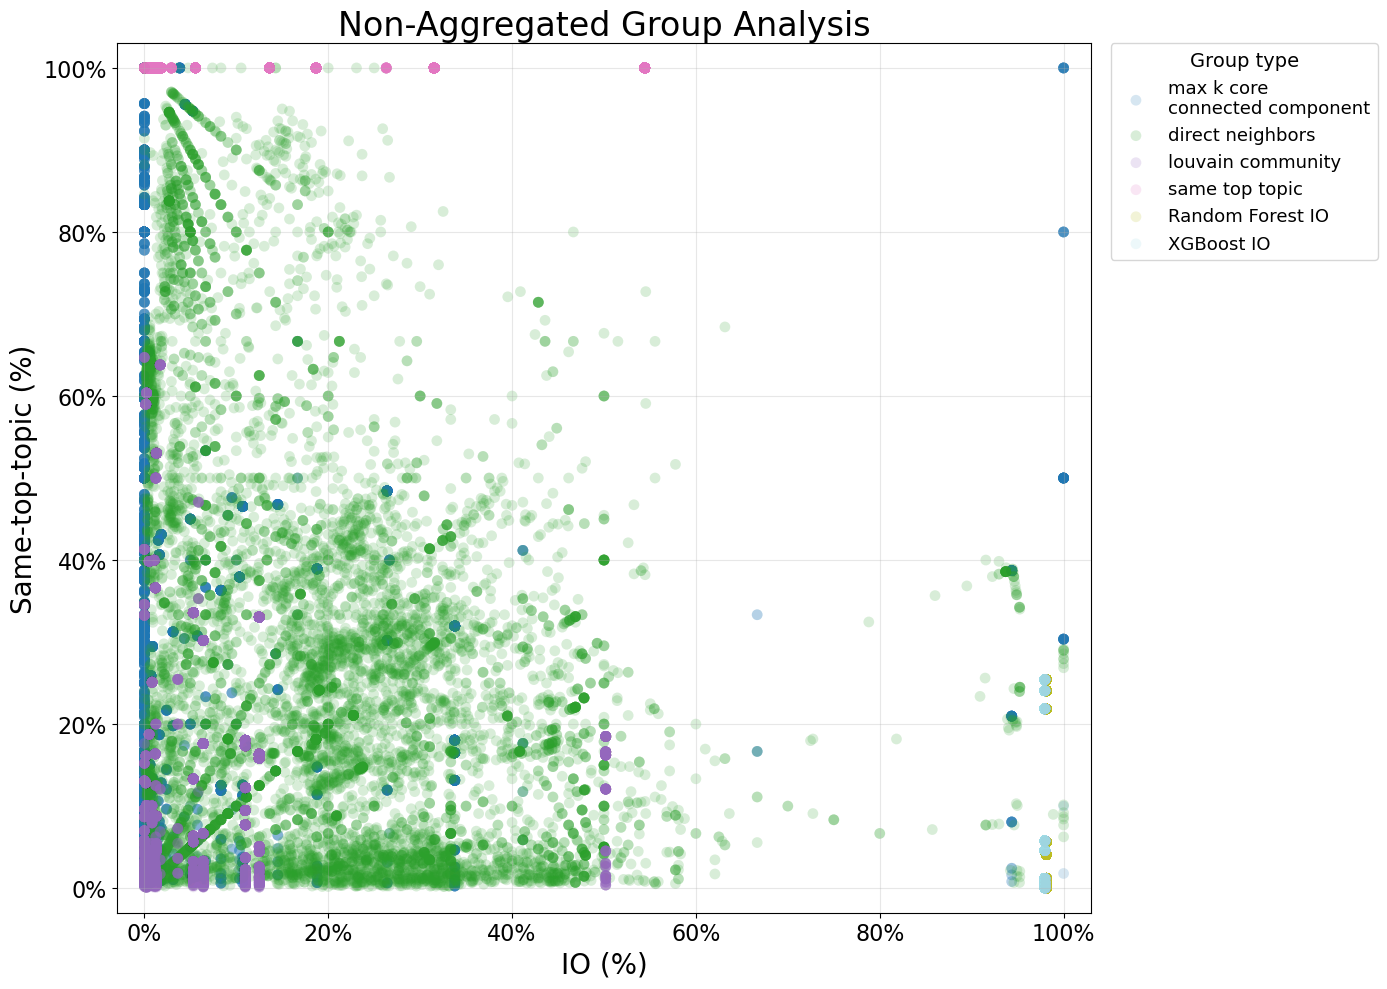

Saved aggregate group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/all_nodes_group_analysis_aggregate_scatter.png


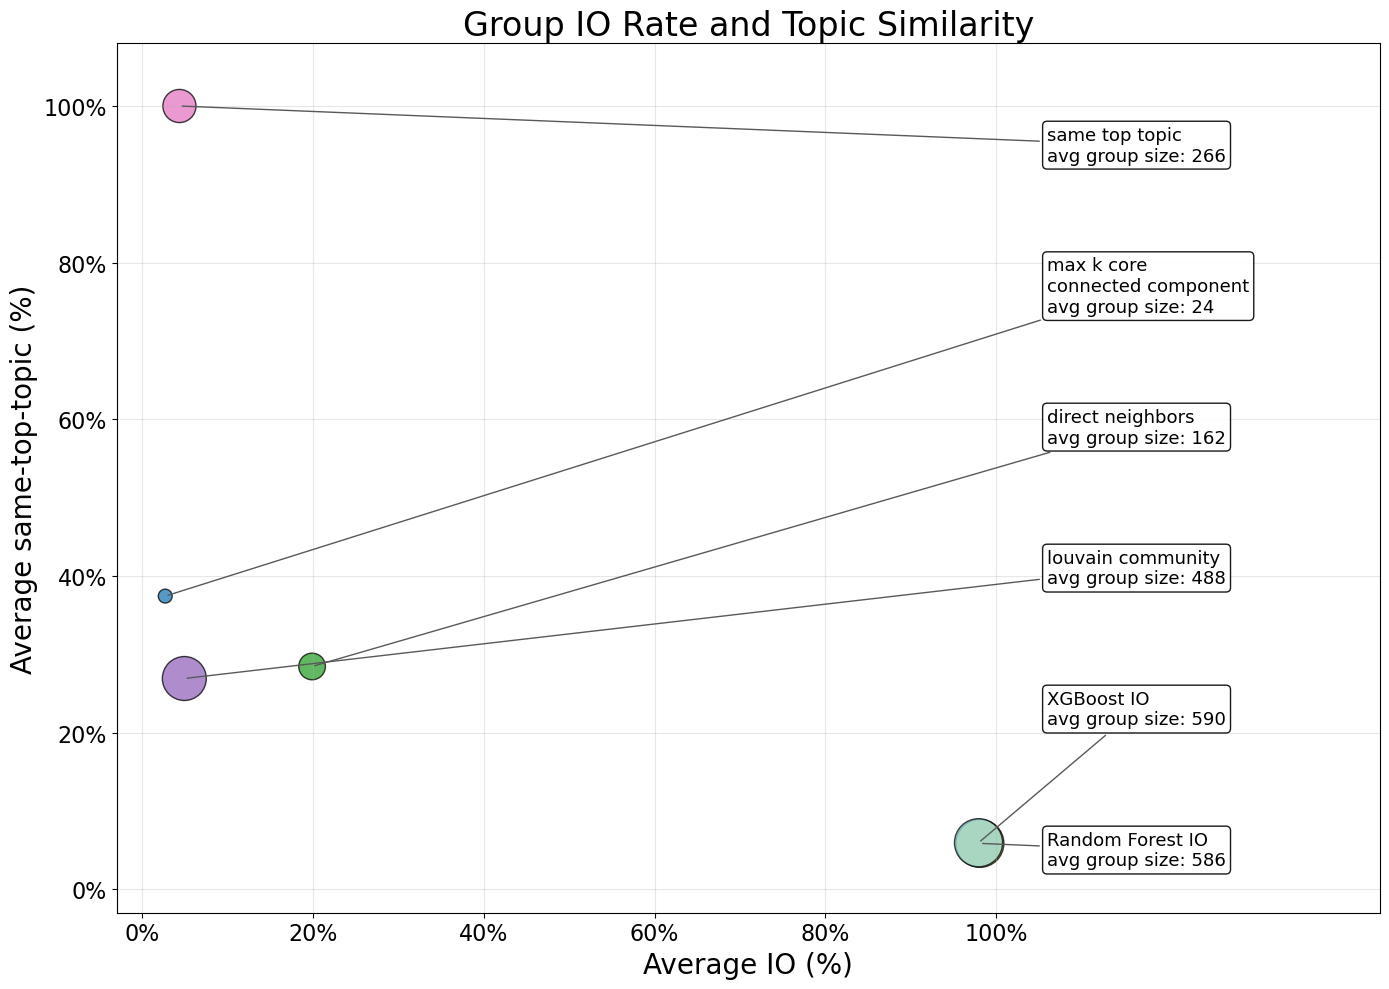

Saved combined group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/all_nodes_group_analysis_combined_scatter.png


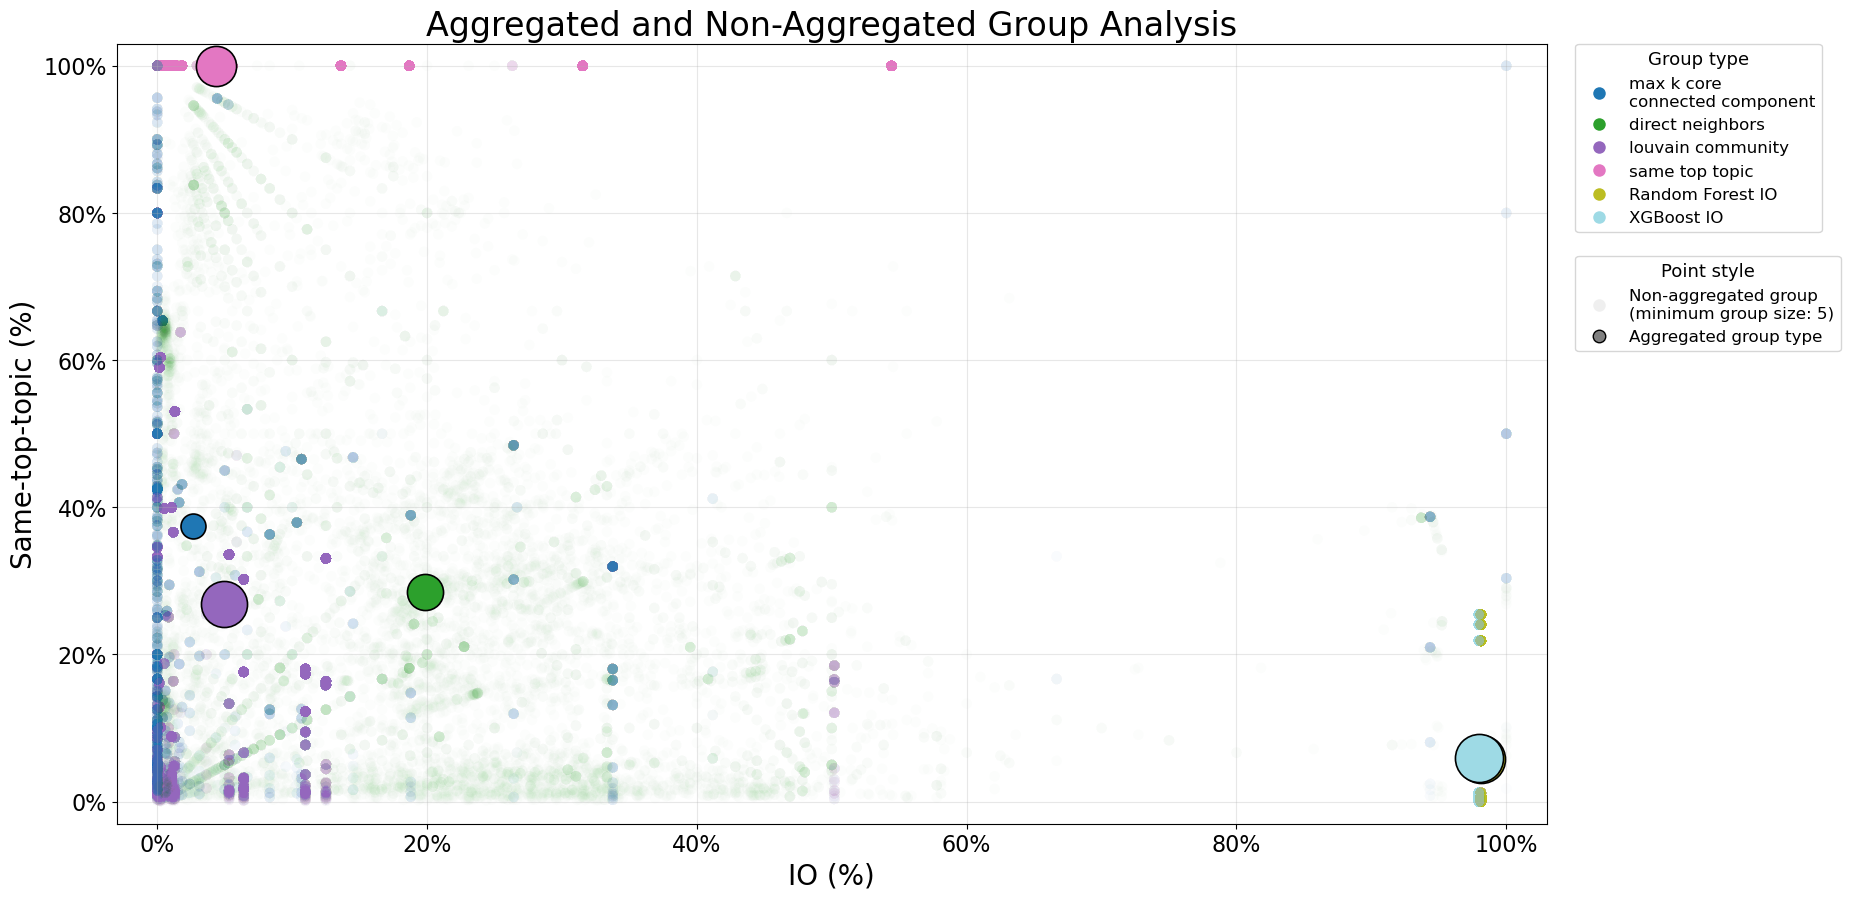

Completed: aggregate_and_plot_group_analysis


In [106]:
group_analysis_aggregate_df = aggregate_and_plot_group_analysis(
    group_analysis_df=all_node_group_analysis_df,
    output_path=group_analysis_folder_path,
    file_name_prefix="all_nodes",
)

### Random Forest predicted-IO authors

Starting build_group_analysis: requested_accounts=586, graph_nodes=10,356, classifier_models=1
[build_group_analysis] Resolving topic and community attributes
[build_group_analysis] Building requested topic and community groups
[build_group_analysis] Computing core numbers


Finding requested k-core groups: 100%|██████████| 36/36 [00:00<00:00, 261.26core/s]


[build_group_analysis] Calculating structural and classifier groups for 586 accounts


Calculating account groups: 100%|██████████| 586/586 [00:00<00:00, 1430.33account/s]


Saved group analysis results to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/rf_io_authors_group_analysis_results.csv


,accountid,group_type,group_id,number_of_nodes,io_percentage,same_top_topic_percentage
0,00bf967d2f076675e040e6286b8785e5e0d44ef7bf,maximal_k_core_component,core=125|component=00bf967d2f076675e040e6286b8...,124,94.354839,20.967742
1,00bf967d2f076675e040e6286b8785e5e0d44ef7bf,direct_neighbors,account=00bf967d2f076675e040e6286b8785e5e0d44e...,133,94.736842,20.300752
2,00bf967d2f076675e040e6286b8785e5e0d44ef7bf,louvain_community,community=54,265,50.188679,12.075472
3,00bf967d2f076675e040e6286b8785e5e0d44ef7bf,same_top_topic,topic=14,1109,13.615870,100.000000
4,00bf967d2f076675e040e6286b8785e5e0d44ef7bf,classifier_predicted_io_random_forest,classifier_io|model=random_forest,586,98.122867,25.426621


Completed: build_group_analysis
Starting aggregate_and_plot_group_analysis: rows=2,930, eligible_rows=2,546, group_types=5, min_group_size=5
Saved aggregate group analysis to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/rf_io_authors_group_analysis_aggregate.csv


,group_type,number_of_unique_groups,average_number_of_nodes,average_io_percentage,average_same_top_topic_percentage
0,maximal_k_core_component,28,80.071429,29.530290,32.284235
1,direct_neighbors,491,635.961303,38.155075,22.231707
2,louvain_community,10,814.200000,8.972030,18.670149
3,same_top_topic,16,496.187500,10.136822,100.000000
4,classifier_predicted_io_random_forest,1,586.000000,98.122867,20.399940


Saved non-aggregated group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/rf_io_authors_group_analysis_non_aggregated_scatter.png


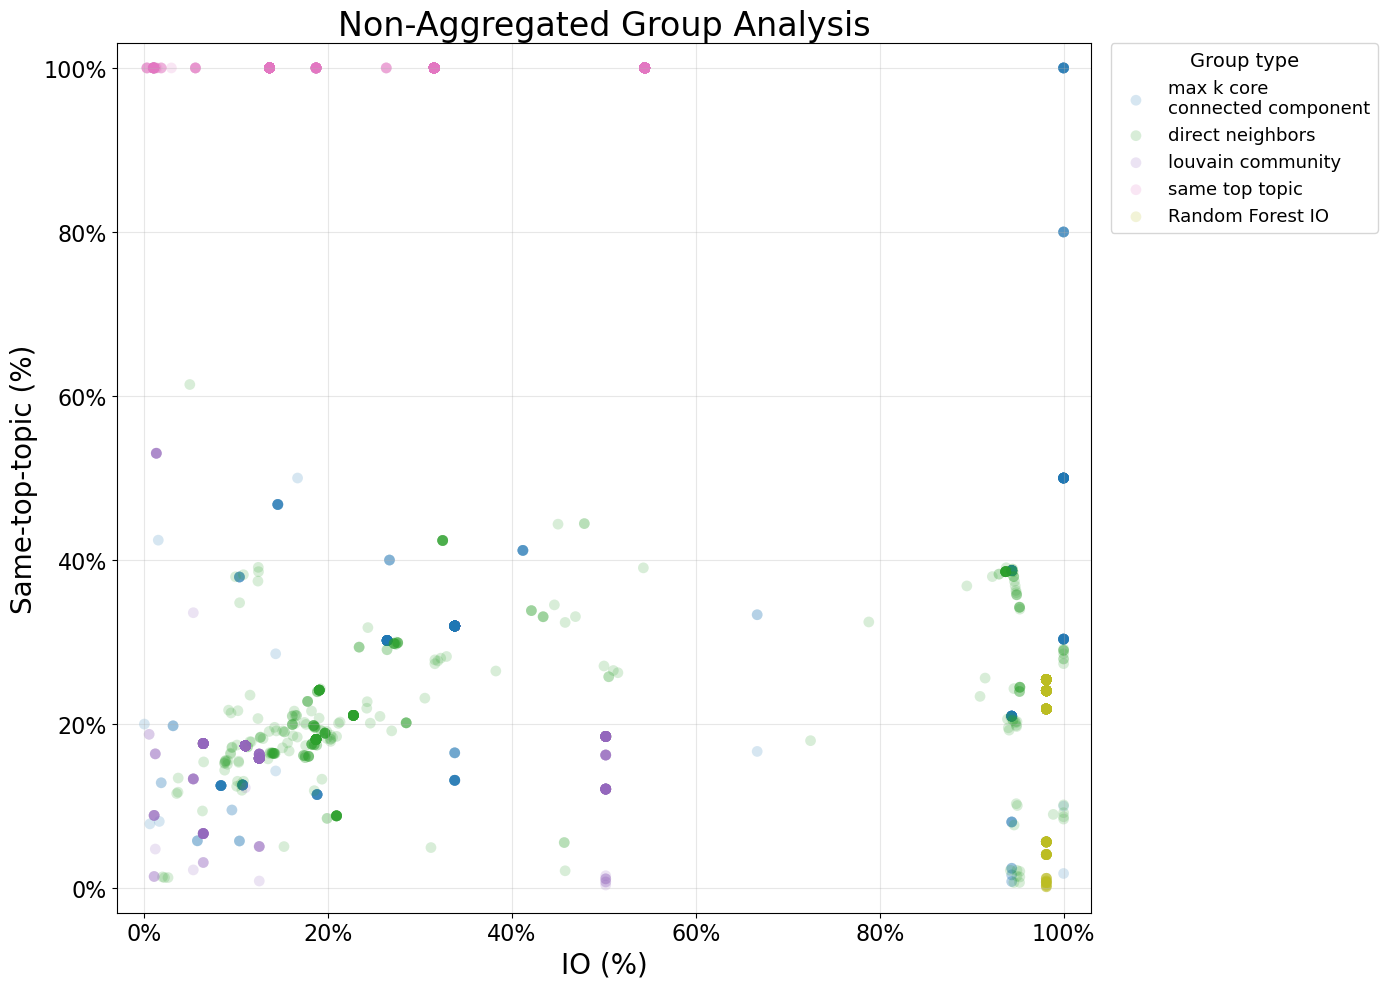

Saved aggregate group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/rf_io_authors_group_analysis_aggregate_scatter.png


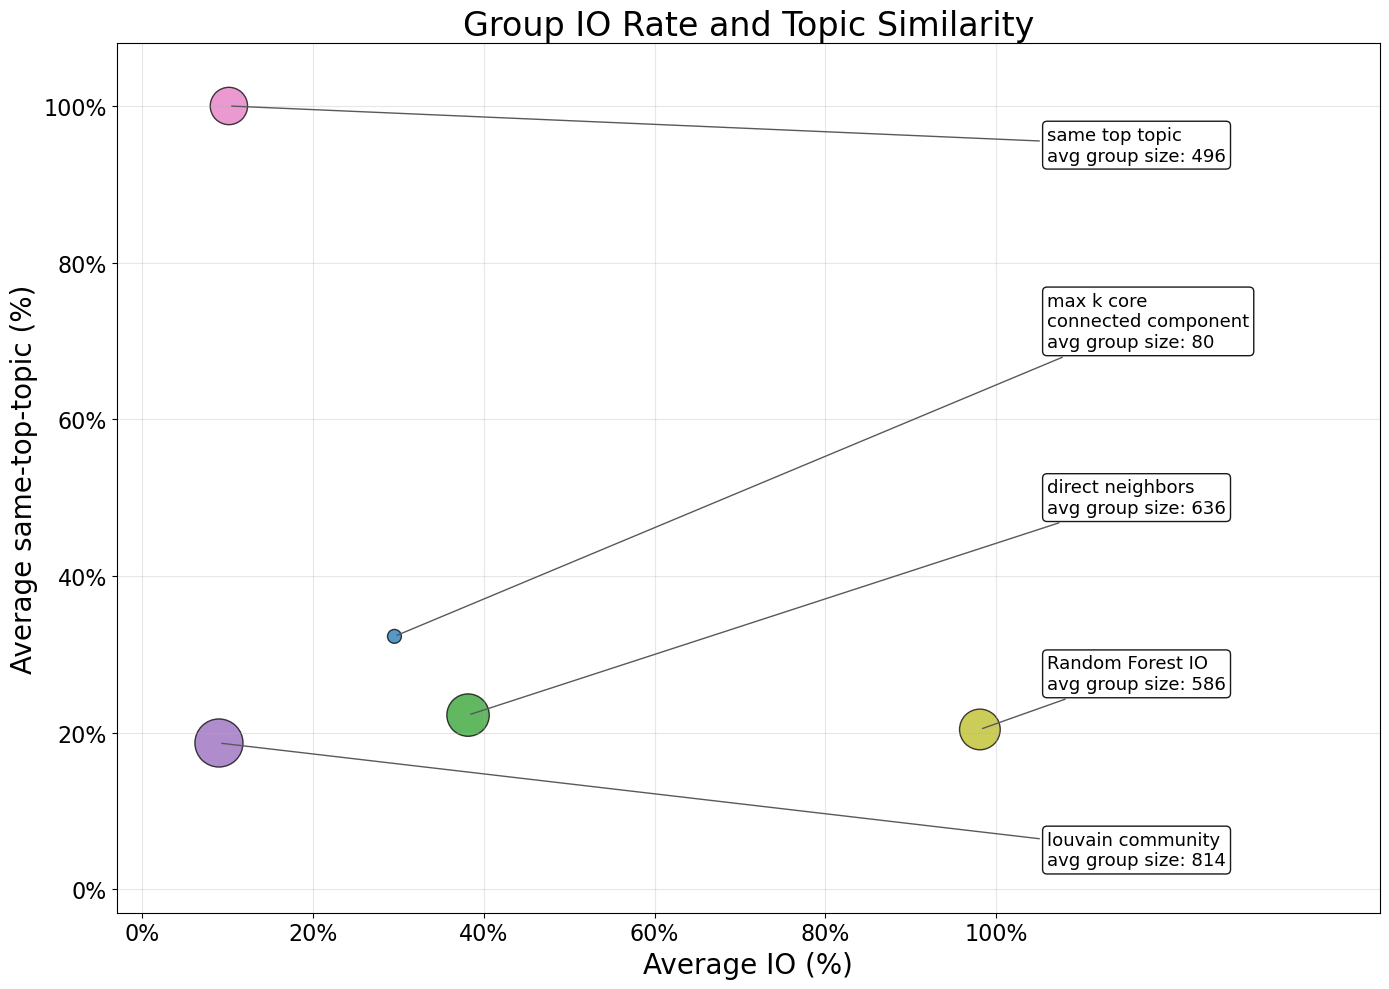

Saved combined group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/rf_io_authors_group_analysis_combined_scatter.png


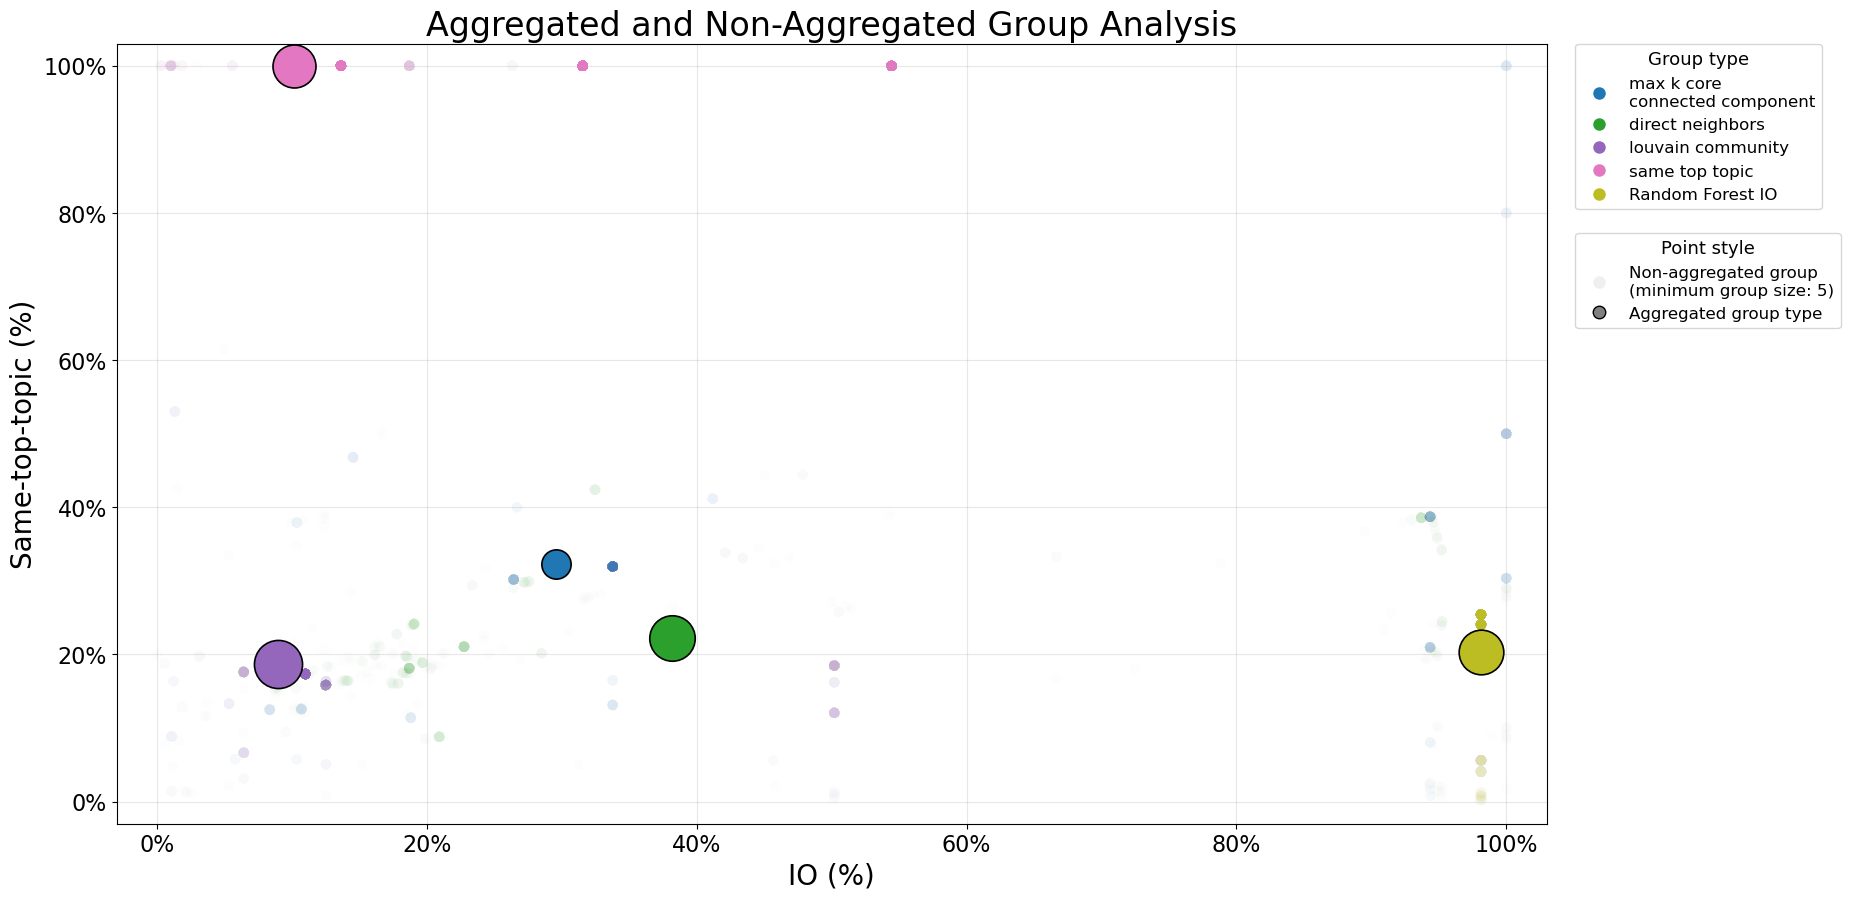

Completed: aggregate_and_plot_group_analysis


In [107]:
rf_io_authors_group_analysis_df = build_group_analysis(
    nodes=classifier_io_authors_by_model["random_forest"],
    G=G_accounts,
    io_authors_set=io_authors_set,
    classifier_io_authors_by_model={
        "random_forest": classifier_io_authors_by_model["random_forest"]
    },
    node_indicators_df=node_indicators_df,
    output_path=group_analysis_folder_path,
    output_filename="rf_io_authors_group_analysis_results.csv",
)

rf_io_authors_group_analysis_aggregate_df = aggregate_and_plot_group_analysis(
    group_analysis_df=rf_io_authors_group_analysis_df,
    output_path=group_analysis_folder_path,
    file_name_prefix="rf_io_authors",
)

### XGBoost predicted-IO authors

Starting build_group_analysis: requested_accounts=590, graph_nodes=10,356, classifier_models=1
[build_group_analysis] Resolving topic and community attributes
[build_group_analysis] Building requested topic and community groups
[build_group_analysis] Computing core numbers


Finding requested k-core groups: 100%|██████████| 40/40 [00:00<00:00, 273.26core/s]


[build_group_analysis] Calculating structural and classifier groups for 590 accounts


Calculating account groups: 100%|██████████| 590/590 [00:00<00:00, 1941.65account/s]

Saved group analysis results to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/xgb_io_authors_group_analysis_results.csv


,accountid,group_type,group_id,number_of_nodes,io_percentage,same_top_topic_percentage
0,00bf967d2f076675e040e6286b8785e5e0d44ef7bf,maximal_k_core_component,core=125|component=00bf967d2f076675e040e6286b8...,124,94.354839,20.967742
1,00bf967d2f076675e040e6286b8785e5e0d44ef7bf,direct_neighbors,account=00bf967d2f076675e040e6286b8785e5e0d44e...,133,94.736842,20.300752
2,00bf967d2f076675e040e6286b8785e5e0d44ef7bf,louvain_community,community=54,265,50.188679,12.075472
3,00bf967d2f076675e040e6286b8785e5e0d44ef7bf,same_top_topic,topic=14,1109,13.615870,100.000000
4,00bf967d2f076675e040e6286b8785e5e0d44ef7bf,classifier_predicted_io_xgboost,classifier_io|model=xgboost,590,97.966102,25.423729


Completed: build_group_analysis
Starting aggregate_and_plot_group_analysis: rows=2,950, eligible_rows=2,576, group_types=5, min_group_size=5
Saved aggregate group analysis to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/xgb_io_authors_group_analysis_aggregate.csv


,group_type,number_of_unique_groups,average_number_of_nodes,average_io_percentage,average_same_top_topic_percentage
0,maximal_k_core_component,31,78.806452,26.815889,34.908471
1,direct_neighbors,499,628.685371,38.506559,22.381443
2,louvain_community,10,814.200000,8.972030,18.726882
3,same_top_topic,15,523.600000,10.734179,100.000000
4,classifier_predicted_io_xgboost,1,590.000000,97.966102,20.529912


Saved non-aggregated group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/xgb_io_authors_group_analysis_non_aggregated_scatter.png


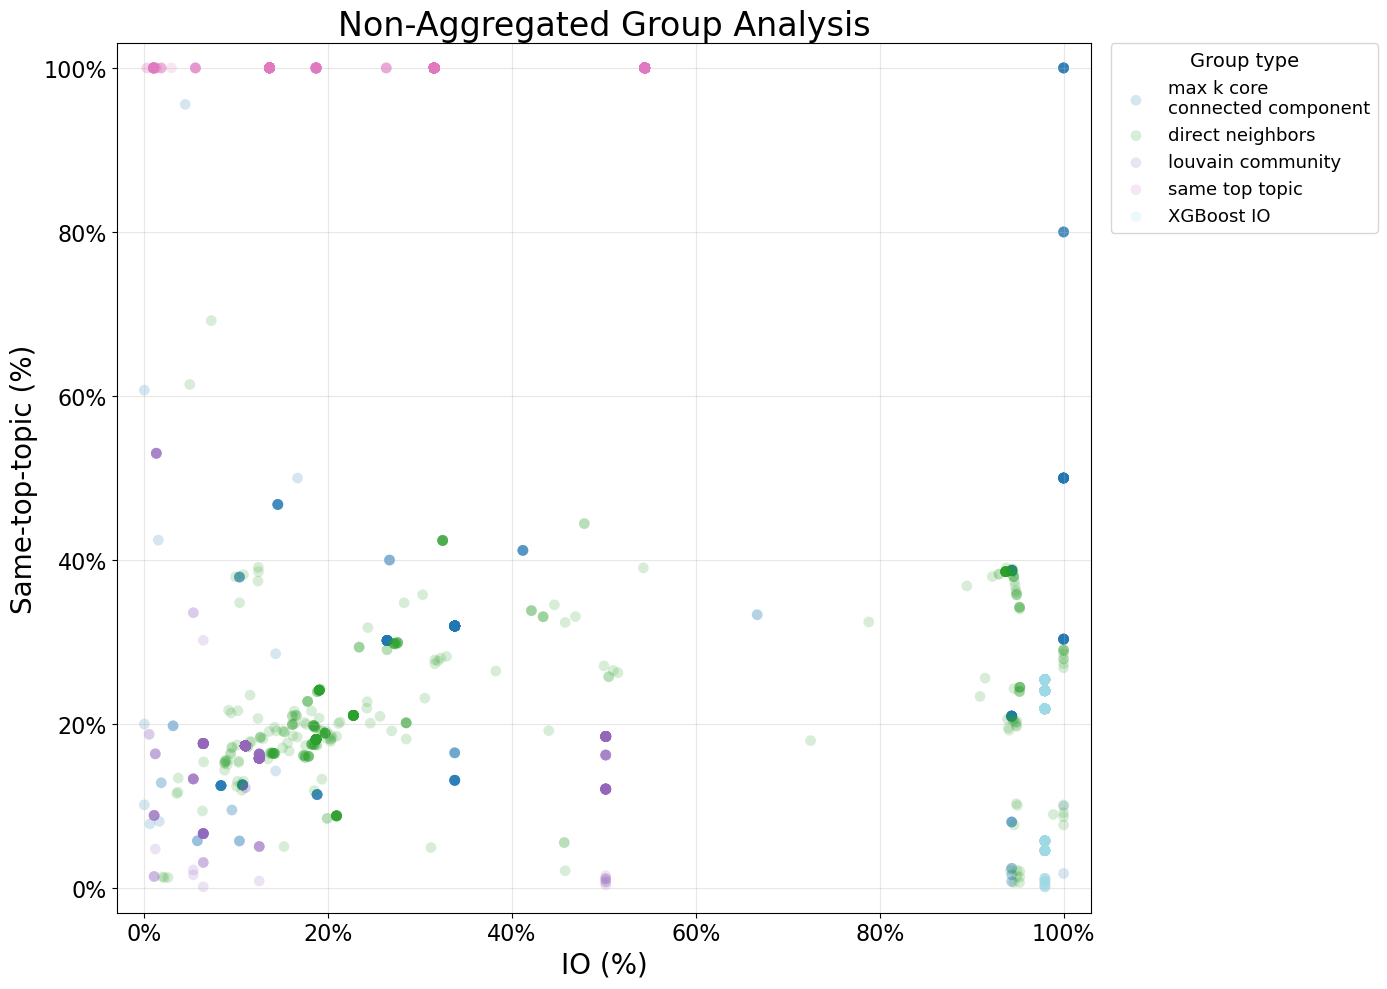

Saved aggregate group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/xgb_io_authors_group_analysis_aggregate_scatter.png


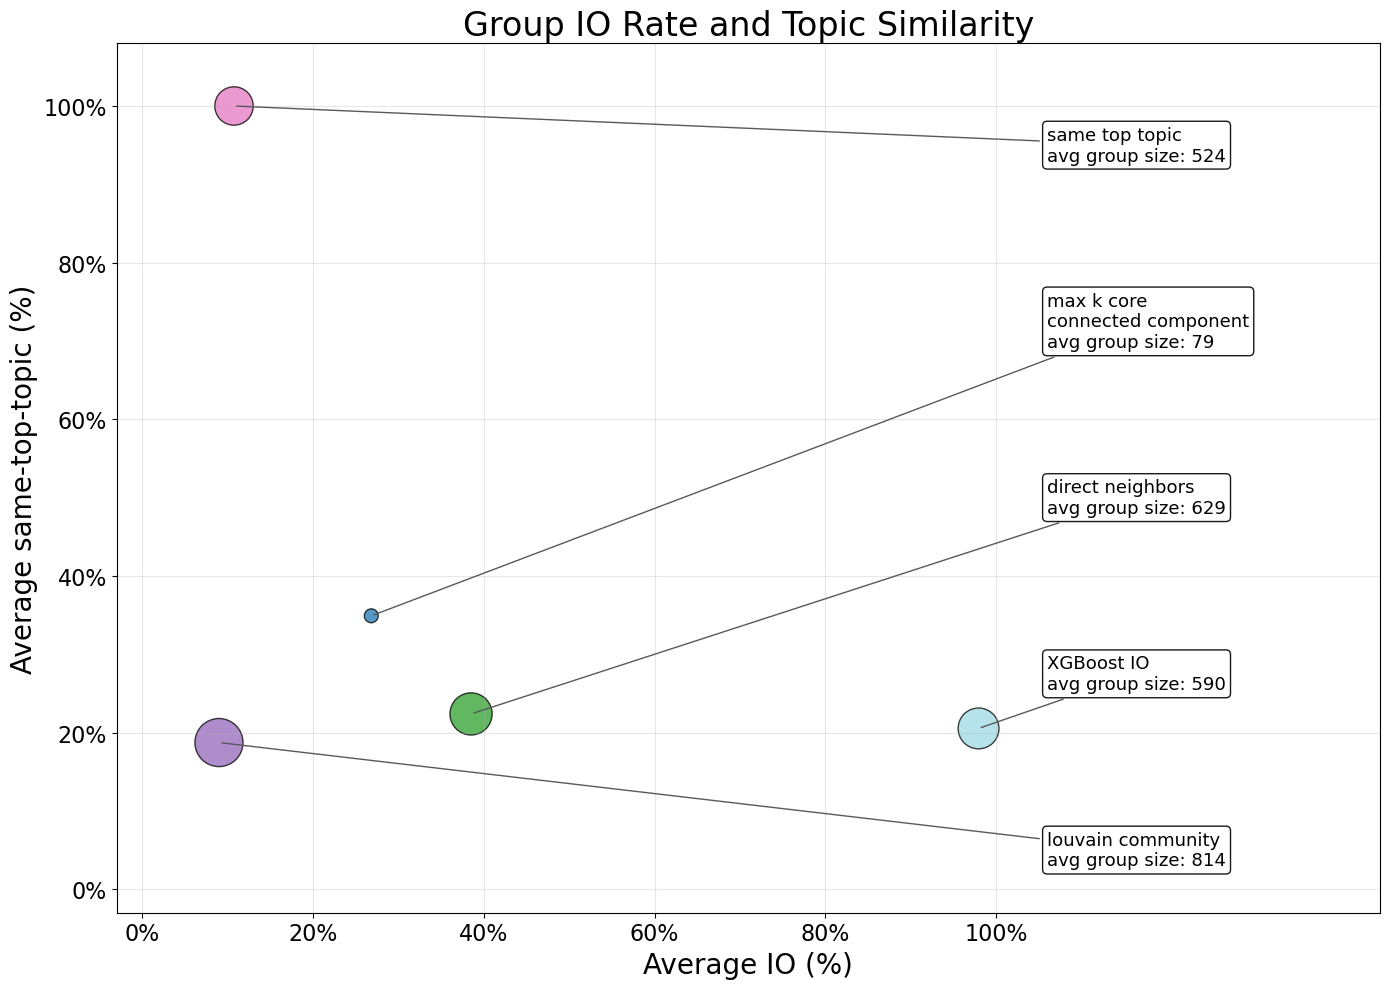

Saved combined group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/xgb_io_authors_group_analysis_combined_scatter.png


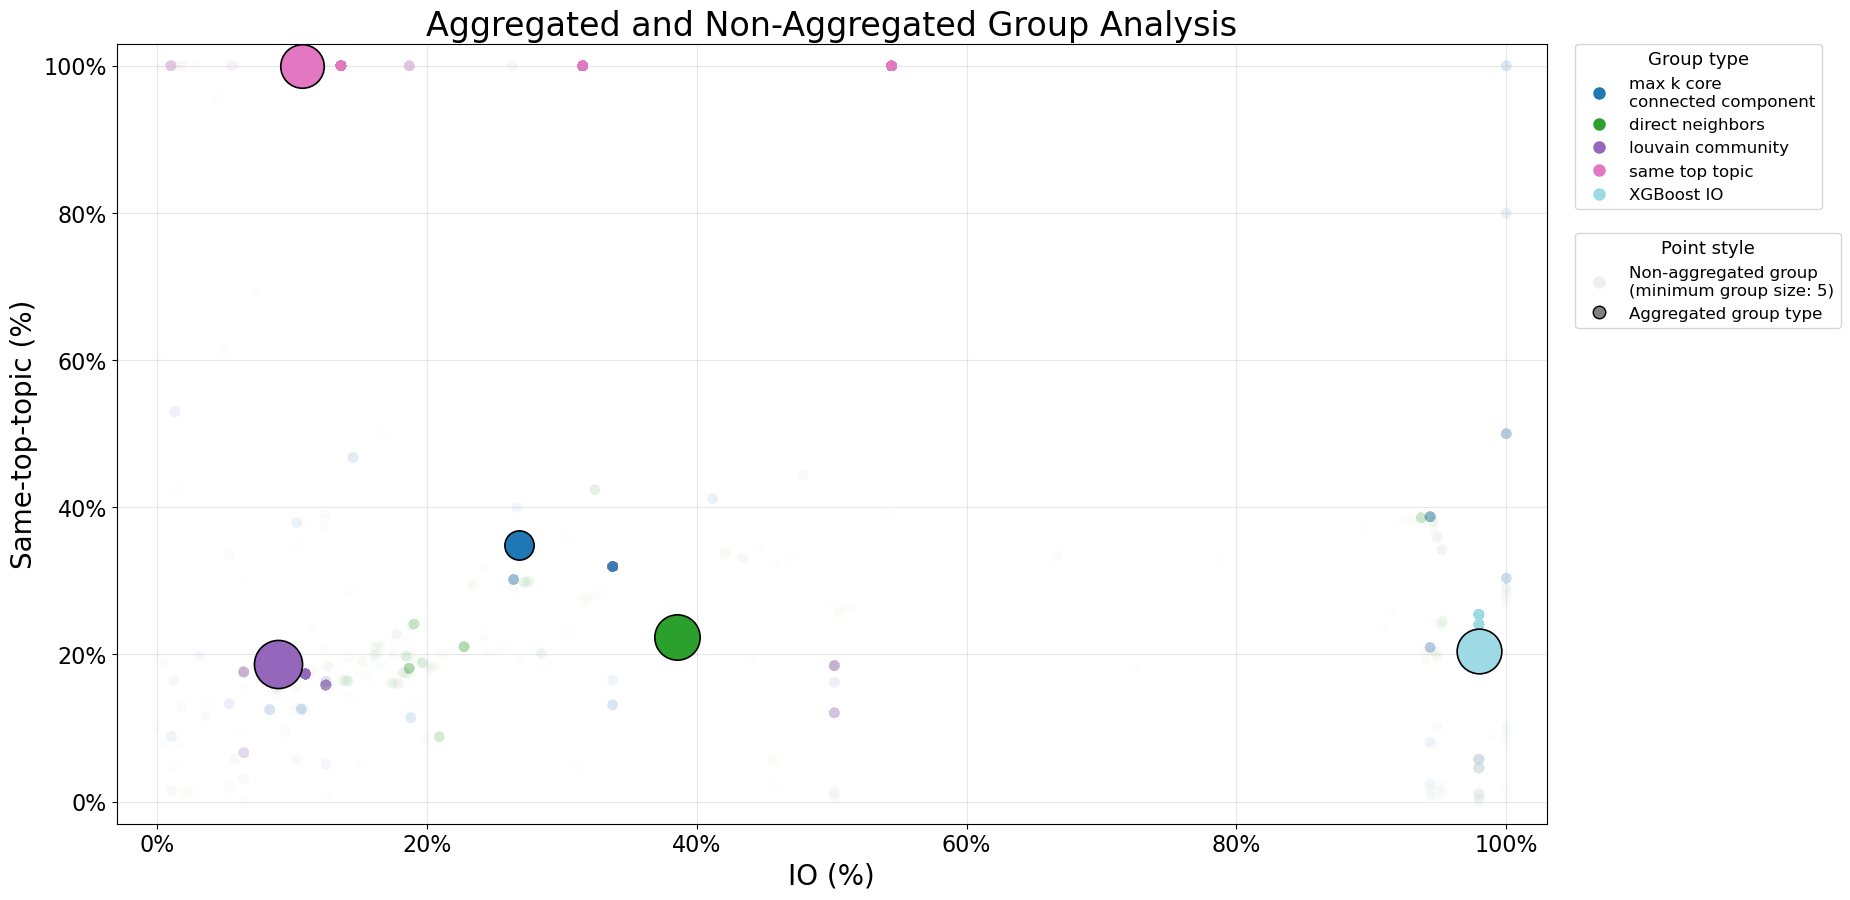

Completed: aggregate_and_plot_group_analysis


In [108]:
xgb_io_authors_group_analysis_df = build_group_analysis(
    nodes=classifier_io_authors_by_model["xgboost"],
    G=G_accounts,
    io_authors_set=io_authors_set,
    classifier_io_authors_by_model={
        "xgboost": classifier_io_authors_by_model["xgboost"]
    },
    node_indicators_df=node_indicators_df,
    output_path=group_analysis_folder_path,
    output_filename="xgb_io_authors_group_analysis_results.csv",
)

xgb_io_authors_group_analysis_aggregate_df = (
    aggregate_and_plot_group_analysis(
        group_analysis_df=xgb_io_authors_group_analysis_df,
        output_path=group_analysis_folder_path,
        file_name_prefix="xgb_io_authors",
    )
)

## Analyze Group Topics

In [109]:
top_core_authors_df = get_top_authors_by_indicator(
    node_indicators_df,
    indicator_col="core_number",
    n=10,
)
top_core_user = top_core_authors_df.index[0]

core_numbers = nx.core_number(G_accounts)
top_core_user_k_core_nodes = get_node_k_core(
    node_id=top_core_user,
    G=G_accounts,
    core_numbers=core_numbers,
    include_node=False,
)

print(top_core_user_k_core_nodes)

Starting get_top_authors_by_indicator: authors=10,356, indicator_col=core_number, top_n=10
keep is set to 'first', meaning: prioritize the first occurrences when values are tied.
Completed: get_top_authors_by_indicator
Starting get_node_k_core: node_id=010dbdd1604f801a973086c991a38bcbbebf303c3d, nodes=10,356, include_node=False
[get_node_k_core] Node '010dbdd1604f801a973086c991a38bcbbebf303c3d' is in k-core 385 with 388 nodes.
{'868fe132b57d75b0d6a54c8a79e59333b0bfdf36bc', 'ef9ef02853f10fcbf28feef3ab4de168f4df812691', '62b13a512c4947f3a7d7f97bd2f77294210442e669', 'e9003cc625a31858437ed031ecdc24763014100733', 'a021bbcd23fd7721997b0dc0bb888af47016c45ebb', '31f8c9eb359a04654713ae73b64dcf874619e1f111', 'b25288e1647c45f074268254c493744845f50b0fcb', 'fcdb35cc16d46c07459043ac1027c56eda9ab06832', '6e8d254f70aaaa2731f0823cbd4be286a53b3bc738', '684c96e21c5759c1c26f56a697a93a9fda11473414', 'b4037b0165cc10aca4327c86195a0392bc4675f4b4', 'cd2453e04a510ab62114d97ab7205c90ae829b9454', '7ed638789d1d80c

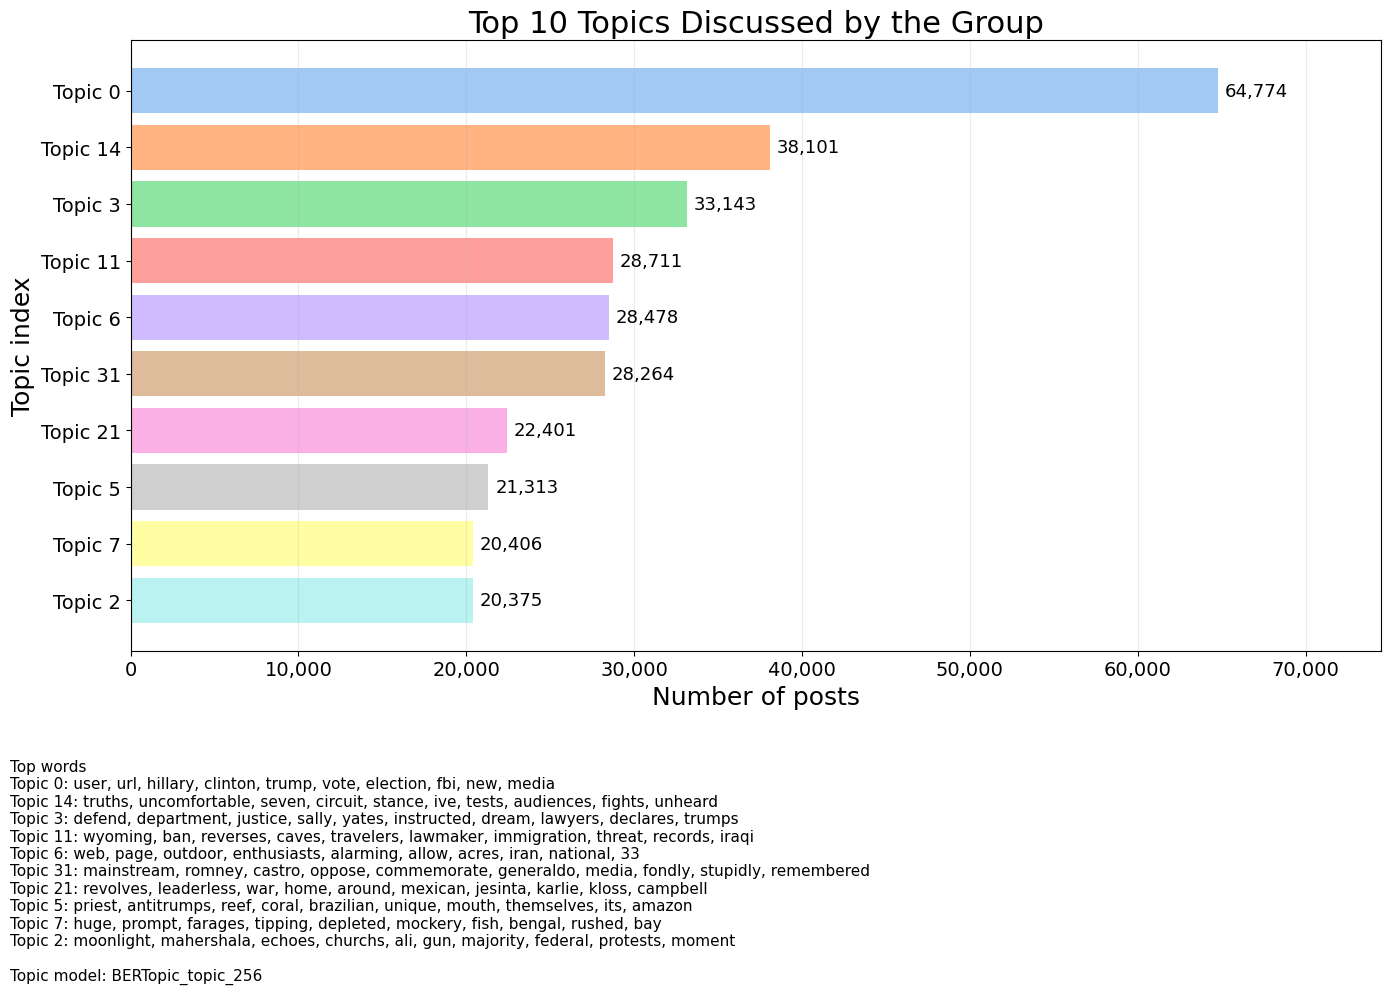

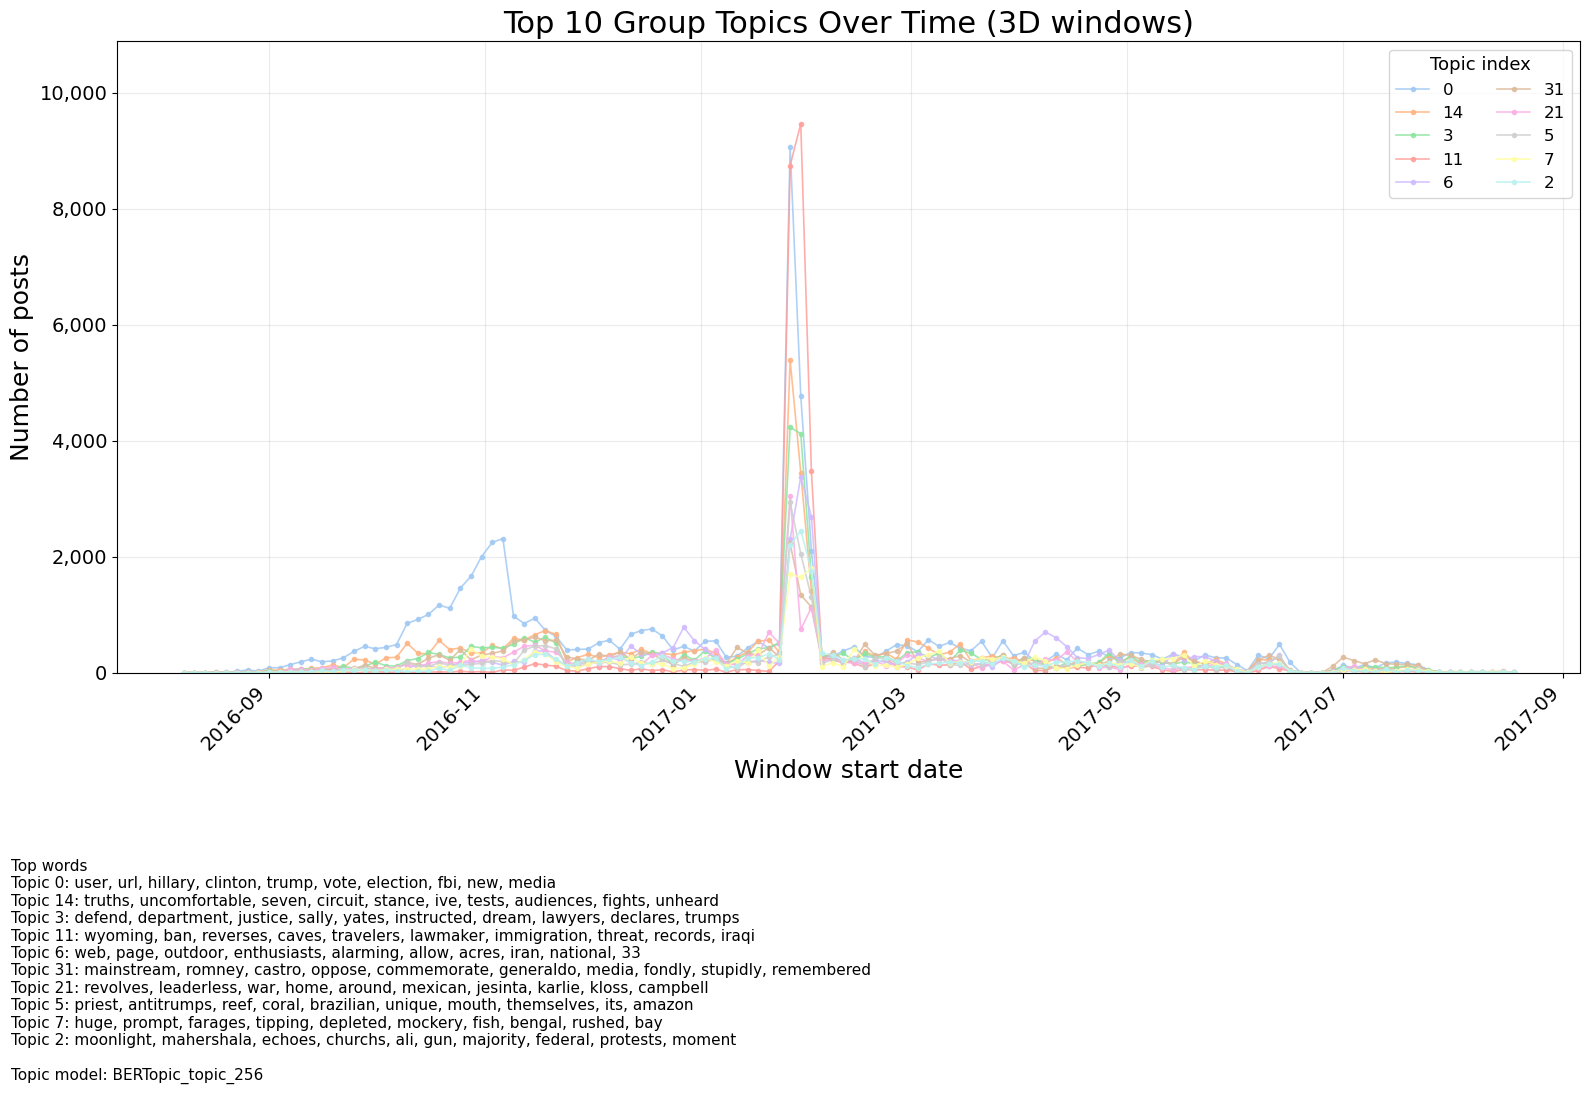

Saved temporal topic counts to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/top_core_user_k_core_group_topics/group_topic_counts_BERTopic_topic_256_3D.csv
Saved topic distribution plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/top_core_user_k_core_group_topics/group_topic_distribution_BERTopic_topic_256.png
Saved temporal topic plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/top_core_user_k_core_group_topics/group_topics_over_time_BERTopic_topic_256_3D.png


,start_date,end_date,BERTopic_topic_256,post_count,topic_top_words
0,2016-08-08,2016-08-11,0,2,"user, url, hillary, clinton, trump, vote, elec..."
1,2016-08-08,2016-08-11,13,2,"agency, yachts, agents, corrupt, tweeted, supp..."
2,2016-08-08,2016-08-11,3,1,"defend, department, justice, sally, yates, ins..."
3,2016-08-08,2016-08-11,10,1,"obamacare, cia, treason, linked, ryan, cyberse..."
4,2016-08-08,2016-08-11,31,1,"mainstream, romney, castro, oppose, commemorat..."
5,2016-08-11,2016-08-14,31,4,"mainstream, romney, castro, oppose, commemorat..."
6,2016-08-11,2016-08-14,0,2,"user, url, hillary, clinton, trump, vote, elec..."
7,2016-08-11,2016-08-14,3,2,"defend, department, justice, sally, yates, ins..."
8,2016-08-11,2016-08-14,14,2,"truths, uncomfortable, seven, circuit, stance,..."
9,2016-08-11,2016-08-14,2,1,"moonlight, mahershala, echoes, churchs, ali, g..."


Completed: analyze_group_topics


In [110]:
group_topic_counts_df = analyze_group_topics(
    df=df,
    nodes=top_core_user_k_core_nodes,
    time_window="3D",
    topic_col=topic_col,
    output_path=group_analysis_folder_path / "top_core_user_k_core_group_topics",
)